source: https://github.com/Mye-InfoBank/scRAFIKI/wiki/QC-Guide


# Perfoming QC on AnnData
--> generalized QC guide for all scRNA seq datasets
- input: read/count matrix with added metadata
- goal: filter out bad quality samples, without filtering out rare populations of cells
- usual covariates analyzed for this purpose are 
    - percentage of counts from mitochondrial genes
    - number of genes (features) per barcode
    - number of total counts (library size/count depth) per barcode
- Approach 
    - for small datasets: manual approach via visual outlier search
    - for larger datasets or several ones: automated approach based on the median absolute deviations (MAD) within the distribution of the chosen covariates
- term 'barcode' is used instead of cell, as a barcode may mistakenly tag multiple cells (doublet) or may not tag any cells (empty droplet/well)

In [167]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
#import spatialdata as sd
import os

#sdata = sd.read_zarr(os.path.join("..", "datasets", "xenium.zarr"))
#adata = sdata.tables["table"]
adata = sc.read_h5ad(os.path.join("..", "datasets", "GSM6592055_M8.h5ad"))
adata

AnnData object with n_obs × n_vars = 4992 × 36406
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

## Manual approach

1. Data pre-processing
- label mitochondrial (mt) genes
- calculate the QC covariates (scanpy function 'calculate_qc_metrics')

In [168]:
# source: github copilot
import mygene

mg = mygene.MyGeneInfo()
# Query all human mitochondrial genes by chromosome
results = mg.query('symbol:MT-*', species='human', fields='ensembl.gene, symbol', size=1000)
print("All matches are returned: ", len(results['hits']) < 1000)

# write the ensembl IDs to a set
mt_ensembl_ids = set()
for hit in results['hits']:
    ensg = hit.get('ensembl')
    if isinstance(ensg, list):
        mt_ensembl_ids.update(e['gene'] for e in ensg)
    elif isinstance(ensg, dict):
        mt_ensembl_ids.add(ensg['gene'])

print(len(mt_ensembl_ids))       
print(mt_ensembl_ids)

Input sequence provided is already in string format. No operation performed


All matches are returned:  True
36
{'ENSG00000198888', 'ENSG00000209082', 'ENSG00000198786', 'ENSG00000210117', 'ENSG00000198840', 'ENSG00000210135', 'ENSG00000210196', 'ENSG00000210077', 'ENSG00000210191', 'ENSG00000210049', 'ENSG00000198763', 'ENSG00000210140', 'ENSG00000210100', 'ENSG00000198899', 'ENSG00000210156', 'ENSG00000210184', 'ENSG00000210176', 'ENSG00000228253', 'ENSG00000210082', 'ENSG00000210107', 'ENSG00000210174', 'ENSG00000198804', 'ENSG00000198695', 'ENSG00000210194', 'ENSG00000210112', 'ENSG00000210154', 'ENSG00000210164', 'ENSG00000210127', 'ENSG00000198727', 'ENSG00000198886', 'ENSG00000211459', 'ENSG00000198712', 'ENSG00000198938', 'ENSG00000210144', 'ENSG00000212907', 'ENSG00000210195'}


In [169]:
# label mitochondrial genes
adata.var["mt"] = adata.var_names.isin(mt_ensembl_ids)
print(f"Number of mitochondrial genes: {adata.var['mt'].sum()}")

# calculate the QC covariates
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=True, inplace=True)

Number of mitochondrial genes: 13


2. Visualization of data
- violin plots of covariates
- histograms of feature count and total counts
- scatter plot of all covariates


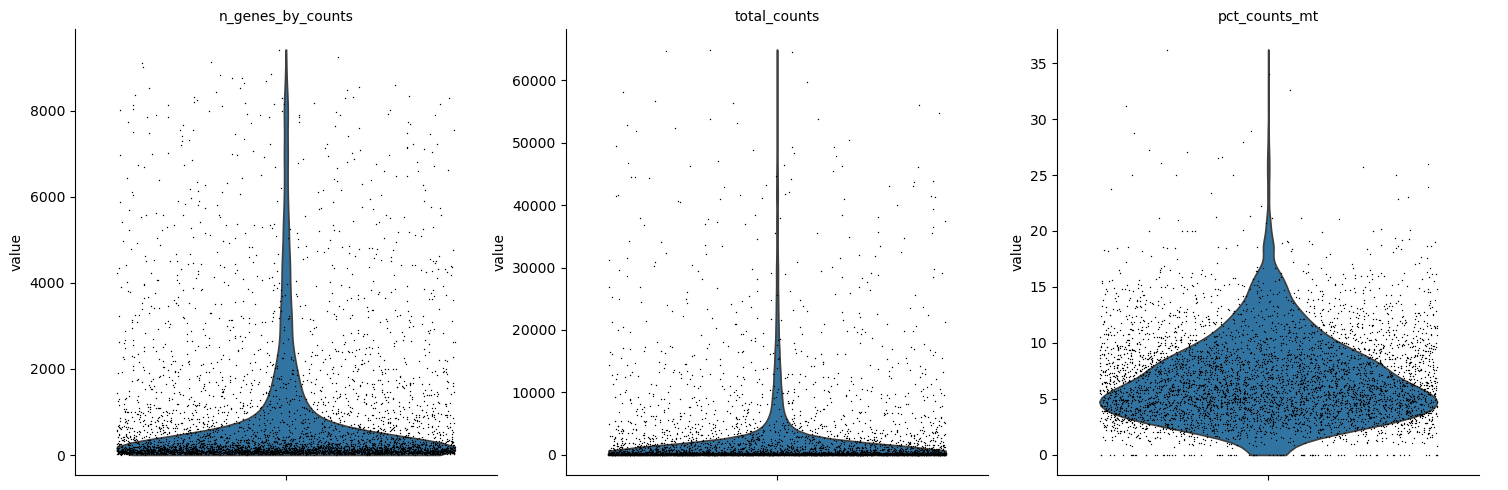

In [170]:
# violin plots of covariates
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

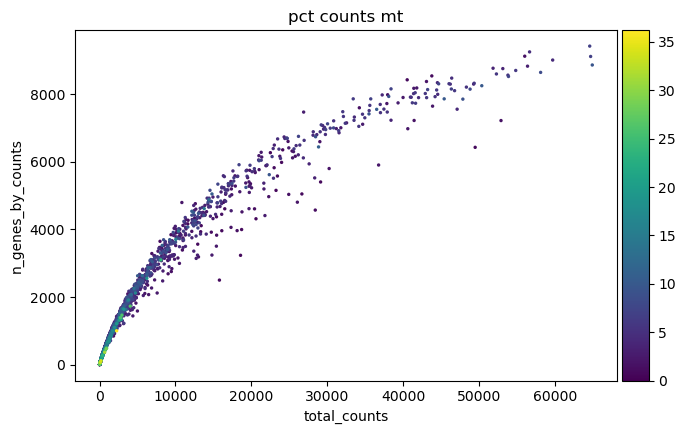

In [171]:
# scatter plot of all covariates
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')

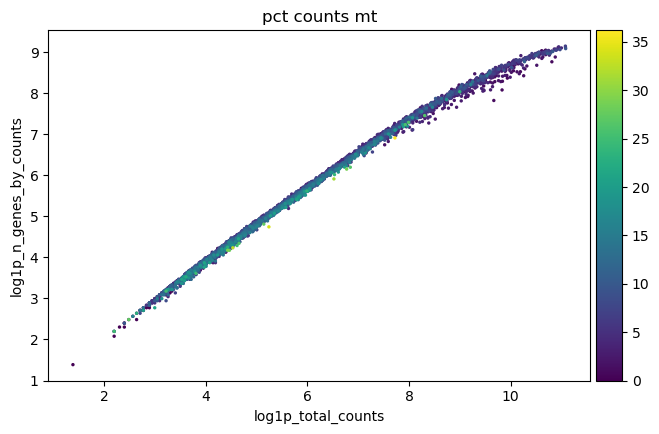

In [172]:
sc.pl.scatter(adata, x='log1p_total_counts', y='log1p_n_genes_by_counts', color='pct_counts_mt')

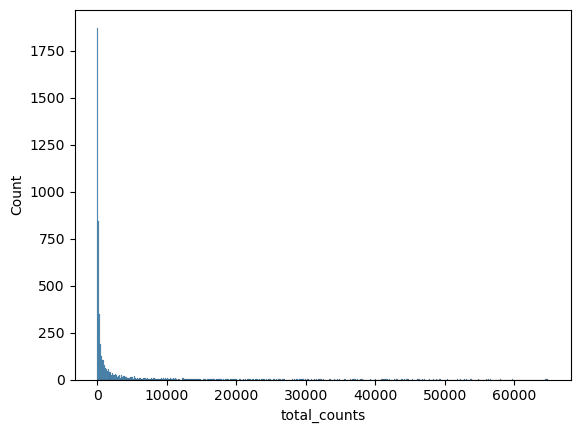

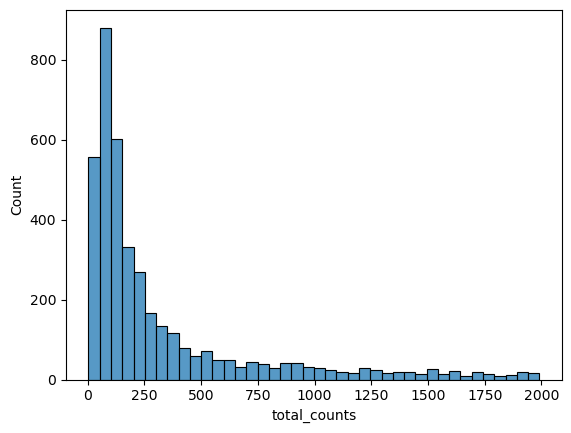

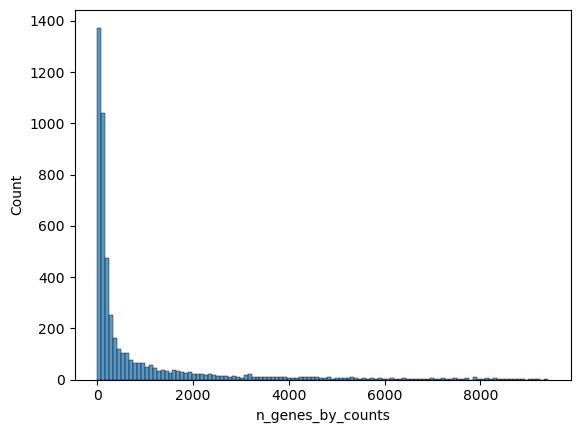

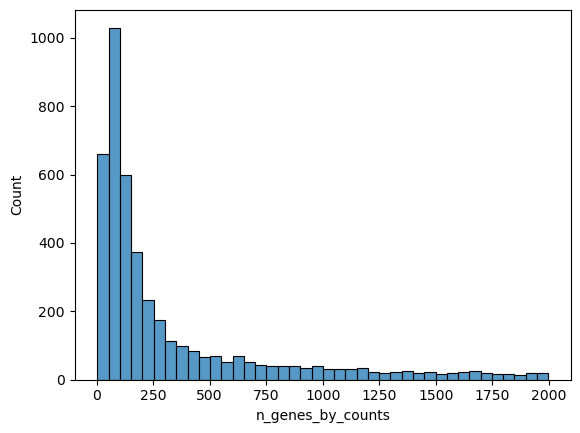

In [173]:
# histograms of feature count and total counts
p1 = sns.histplot(adata.obs['total_counts'])
plt.show()
p3 = sns.histplot(adata.obs['total_counts'][adata.obs['total_counts']<2000], bins = 40)
plt.show()
p5 = sns.histplot(adata.obs['n_genes_by_counts'])
plt.show()
p7 = sns.histplot(adata.obs['n_genes_by_counts'][adata.obs['n_genes_by_counts']<2000], bins = 40)
plt.show()

3. Filter with manually set thresholds
- filter cells with high fraction of mitochondrial genes
- filter cells with low feature count (not enough genes expressed)
- filter cells with low total count (not enough reads captured or sequenced)
- filter cells with too many total counts ( probably doublets, but doublet removal is also handled by SIMBA🦁, so not necessary here)
- filter genes expressed in only a few cells (optional, SIMBA🦁 will have a threshold of at least 10 cells lateron anyways but over all datasets included for the atlas)

In [174]:
print(f'Total number of cells: {adata.n_obs}')
print(f'Total number of genes: {adata.n_vars}')
 
adata = adata[adata.obs['pct_counts_mt'] < 20]
print(f'Number of cells after MT filter: {adata.n_obs}')

sc.pp.filter_cells(adata, min_genes = 100)
print(f'Number of cells after gene filter: {adata.n_obs}')

sc.pp.filter_cells(adata, min_counts=150)
print(f'Number of cells after count filter: {adata.n_obs}')

sc.pp.filter_genes(adata, min_cells=2)
print(f'Number of genes after cell filter: {adata.n_vars}')

Total number of cells: 4992
Total number of genes: 36406
Number of cells after MT filter: 4951


c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\scanpy\preprocessing\_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


Number of cells after gene filter: 3323
Number of cells after count filter: 2956
Number of genes after cell filter: 20279


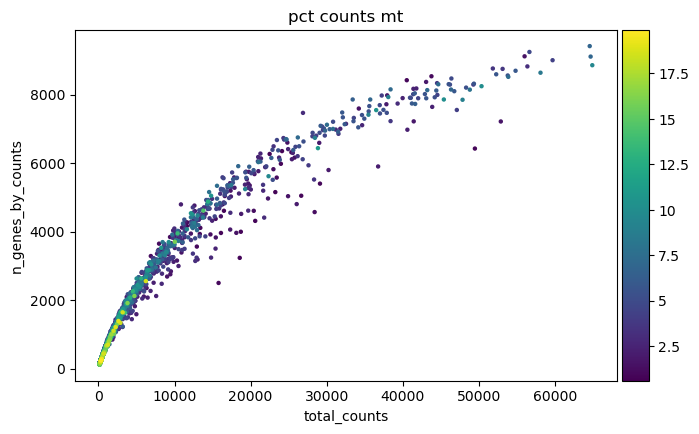

In [175]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')

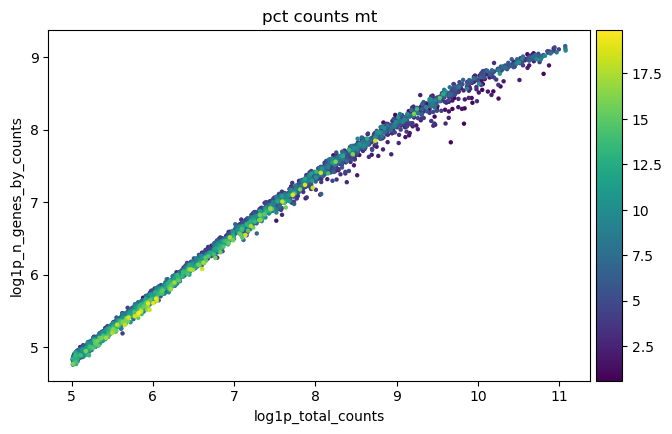

In [176]:
sc.pl.scatter(adata, x='log1p_total_counts', y='log1p_n_genes_by_counts', color='pct_counts_mt')

## Automated approach

- method for relative quality filtering: MAD (median absolute deviation)
- A deviation between 3-5 is usually seen as good practice.
- MAD = median(|X_i - median(X)|) with (X_i) being the respective QC metric of an observation

In [177]:
adata = sc.read_h5ad(os.path.join("..", "datasets", "GSM6592055_M8.h5ad"))
adata

AnnData object with n_obs × n_vars = 4992 × 36406
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

In [178]:
adata.var["mt"] = adata.var_names.isin(mt_ensembl_ids)
print(f"Number of mitochondrial genes: {adata.var['mt'].sum()}")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=[20],log1p=True)

Number of mitochondrial genes: 13


- a "relatively mild filtering provides a good trade-off, often leading to high clustering performance while retaining most of the cells in each subpopulation" 
- default set of filters in which cells are excluded if they are outliers in at least 2:
    - log10_total_counts >2.5 MADs or <5 MADs,
    - log10_total_features >2.5MADs or <5MADs,
    - pct_counts_in_top_20_features > or <5MADs,
    - pct_counts_Mt >2.5 MADs and >8%.
- Removal of ribosomal genes robustly reduced the quality of the clustering

In [179]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M)
    return outlier

In [180]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    4704
True      288
Name: count, dtype: int64

In [181]:
# mitochondrial gene fraction
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    3430
True     1562
Name: count, dtype: int64

In [182]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 4992
Number of cells after filtering of low quality cells: 3261


In [ ]:
# not in source
print(f"Total number of cells: {adata.n_vars}")
sc.pp.filter_genes(adata, min_cells=1)
print(f'Number of genes after cell filter: {adata.n_vars}')

Total number of cells: 36406
Number of genes after cell filter: 22116


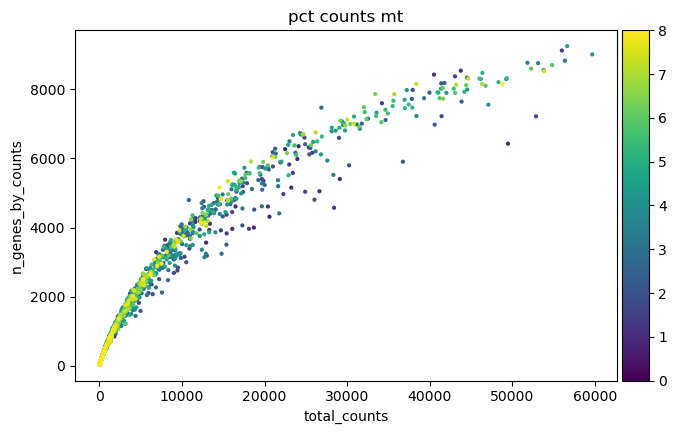

In [184]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")